# Semantic caching from scratch with Oracle AI Database

A **semantic cache** reuses a stored LLM answer when a new question *means* the same thing as one
the agent has already answered, even when the words differ. This notebook builds one from first
principles with plain SQL: a local open-source embedding model turns each question into a vector,
Oracle AI Database stores the vectors in a `VECTOR` column behind an HNSW index, and a
cross-encoder reranker double-checks every candidate before a cached answer is served.

The agent is a **developer-support agent** that answers engineers' programming questions. Its
traffic comes from real data: the StackExchange duplicates dataset on Hugging Face, which holds
pairs of question titles that StackExchange communities marked as asking the same thing.

**What you will build and measure**

- An Oracle table and HNSW vector index that hold cached answers, scoped by tenant, model and
  prompt version, with an expiry time on every row.
- A two-stage acceptance policy (vector distance, then reranker verification) whose thresholds
  are chosen from measured duplicate recall and false-hit rates, not guessed.
- An agent function that answers from the cache or calls Claude, with latency and cost recorded
  for every step.
- The cases that must miss (a look-alike question, another tenant, an expired entry), and a
  known failure that slips through both checks, plus a guard for it.

**What you need**

- An Anthropic API key: Claude writes the answer whenever the cache misses.
- An Oracle AI Database 23ai (or later) schema with `CREATE TABLE`, a tablespace quota and a
  vector memory pool for the HNSW index, supplied through `ORACLE_USER`, `ORACLE_PASSWORD` and
  `ORACLE_DSN` (or typed when prompted).
- Internet access on the first run to download the dataset file and two small open-source models
  from Hugging Face. Both models then run locally on the CPU; no question text leaves your
  machine except the ones sent to Claude.

### Install the notebook packages

Use a **Python 3.12** kernel. Open this notebook from the `cache_techniques` folder so `requirements.txt` is available. Run the next cell before Part 1: **%pip** installs into the Python environment used by this notebook's active kernel.

`requirements.txt` installs **anthropic** for Claude, **sentence-transformers** for the open-source Hugging Face embedding model and reranker (it brings PyTorch and transformers), **oracledb** and **langchain-oracledb** for Oracle AI Database, **tavily-python** for web search, **pandas**, **pyarrow** and **huggingface_hub** for reading public Hugging Face datasets, and **numpy** and **matplotlib** for measurements and charts. It also installs JupyterLab, plus nbformat and nbclient, which `tests/run_notebooks.py` uses to run a notebook end to end.

After the first installation finishes, **restart the kernel**, then run the Parts in order. Installation needs internet access; it does not need your API keys.

In [1]:
# Install packages into this notebook's active Python kernel.
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Part 1 · How semantic caching works

## 1.1 · The idea

An exact cache is a dictionary: it helps only when a request repeats character for character.
People rarely ask the same question the same way twice. "how to use an android timer" and "How to
set timer in android?" are one question to a person and two different keys to a dictionary, so an
exact cache misses and the agent pays for a second, nearly identical answer.

A semantic cache compares **meaning** instead of text. An *embedding model* turns each question
into a vector of numbers. The model is trained so that questions with similar meaning land close
together, which turns "is this the same question?" into "is this vector near a stored vector?".
When a new question arrives, the cache searches for the nearest stored question. If it is close
enough, and passes a second, stricter check, the agent returns the stored answer instead of calling
the LLM.

- **What is reused:** the generated answer text.
- **What is skipped:** the LLM call, usually the slowest and most expensive step of an agent turn
  (seconds of latency, plus paid input and output tokens).
- **What is not skipped:** embedding the new question, searching the database and running the
  reranker on a few candidates. These run on *every* request, hit or miss. A semantic cache adds a
  small cost to every miss in exchange for removing a large cost from every hit.

## 1.2 · The request flow

The diagram shows one request through the cache. The agent application owns the decision; the
models and the database each do one job.

**Figure · One request through the semantic cache**

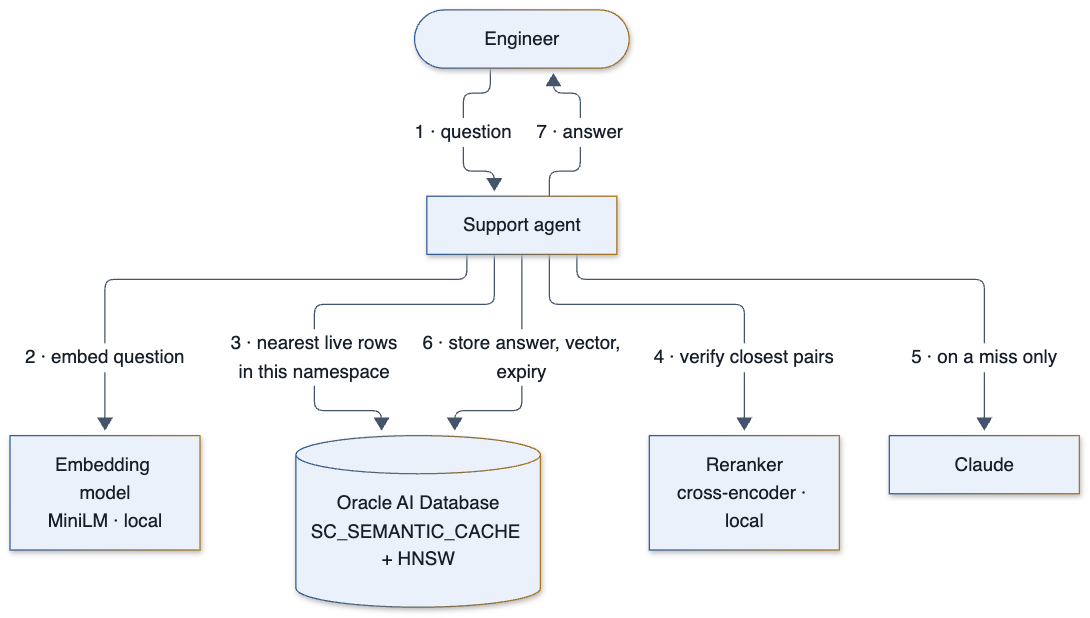

<details><summary>Mermaid source</summary>

```mermaid
flowchart TB
    U([Engineer]) -->|1 · question| A[Support agent]
    A -->|2 · embed question| E["Embedding model<br/>MiniLM · local"]
    A -->|3 · nearest live rows<br/>in this namespace| DB[("Oracle AI Database<br/>SC_SEMANTIC_CACHE + HNSW")]
    A -->|4 · verify closest pairs| R["Reranker<br/>cross-encoder · local"]
    A -->|5 · on a miss only| L[Claude]
    A -->|6 · store answer, vector,<br/>expiry| DB
    A -->|7 · answer| U
```

</details>

1. **Question.** An engineer asks the agent a programming question in the team chat.
2. **Embed.** The agent sends the question text to a local embedding model, which returns a
   384-number vector. The same model must embed both stored and new questions; vectors from two
   different models are not comparable.
3. **Search.** The agent asks Oracle for the stored questions nearest to that vector, but only among
   rows in the same *namespace* (same tenant, model and prompt version) that have not expired.
   The HNSW index makes this an approximate search that touches a small part of the table instead
   of comparing against every row.
4. **Verify.** For the closest candidates, the agent applies its acceptance policy: the distance
   must be under a limit, and a reranker that reads both questions together must agree they ask the
   same thing.
5. **Generate on a miss.** Only when no candidate passes does the agent call Claude.
6. **Store.** The new answer is written to Oracle with its question, vector and an expiry time, so
   the next paraphrase can reuse it.
7. **Answer.** The engineer gets the answer, from the cache (milliseconds) or from Claude (seconds).

## 1.3 · What makes two requests the same

Two separate conditions must both hold before a stored answer can be reused.

**1. The scope must match exactly.** A *namespace* is a hash of everything that changes what a
correct answer looks like:

- the **tenant**: the team or customer whose conventions the answer reflects;
- the **LLM** and the **prompt version**: a different model or system prompt produces different
  answers, so old answers must not leak into the new configuration;
- the **embedding model and its revision**: the stored vectors are only comparable with vectors
  from the same model files.

The lookup filters on the namespace *before* comparing meaning, so an answer written for one
tenant can never be served to another, however similar the question.

**2. The meaning must be close enough.** This is measured, not known. Embeddings are compared with
*cosine distance*: one minus the cosine of the angle between two vectors. A distance of 0 means
the vectors point the same way; larger values mean less related questions. The model was trained to
put paraphrases close together, but closeness is evidence, not proof:

- Embeddings capture topic and wording well, and **negation, contrast, platform, version and
  numbers** poorly. "How to set a Timer in Java?" sits close to "how to use an android timer", yet
  the right answers differ (`java.util.Timer` against Android's `Handler` or `WorkManager`).
- So this cache uses a **second check**. The embedding model is a *bi-encoder*: it encodes each
  question on its own, which is fast and lets Oracle index the vectors. A *cross-encoder reranker*
  reads the two questions *together*, so every word of one can be compared with every word of the
  other. It is slower (one model pass per pair, no index), so it runs only on the few candidates the
  vector search returns.

## 1.4 · Freshness, expiry and invalidation

A cached answer is a copy of a past output. It goes stale in three ways, and each needs its own
mechanism:

- **Time.** Every row carries `expires_at`, computed by the database clock when the row is written.
  Lookups ignore expired rows immediately; deleting them is a housekeeping job that can run later.
- **Configuration.** Changing the model, the system prompt or the embedding model changes the
  namespace, so old rows simply stop matching and age out. Bumping a version string is the cheapest
  reliable invalidation there is.
- **Knowledge.** When the facts an answer relied on change (a library release, an internal
  convention, a security advisory), delete the affected rows explicitly, for example by namespace
  or by a topic column. Expiry alone would keep serving the old answer until it ran out.

Some questions should never be cached: anything that depends on the time ("what changed today"),
on private state ("why is *my* build failing"), or on a live system.

## 1.5 · When it helps and when it hurts

**It helps** when many requests are paraphrases of a smaller set of questions (FAQ-style support
traffic), when answers are expensive to generate, and when the right answer is stable for hours or
days.

**It hurts** in three ways:

- **Miss overhead.** Every miss pays for embedding, a database round trip and a reranker pass on
  top of the LLM call. With little repetition in the traffic, the cache is mostly overhead.
- **False hits.** The real risk. A false hit serves a confident, well-written answer *to a different
  question*. It costs more than the LLM call it saved, because the engineer may act on it.
- **Staleness.** A cached answer outlives the knowledge it was based on unless something
  invalidates it.

Because a false hit is worse than a miss, the thresholds are tuned for **precision first**: decide
how many false hits you can tolerate, then take as many genuine paraphrases as that budget allows.

### Takeaways

- A semantic cache reuses answers by meaning: embed, search nearest, verify, then reuse or generate.
- Scope (tenant, model, prompt, embedder) must match exactly; meaning only has to be close enough.
- Vector closeness is evidence, not equivalence; a cross-encoder reranker is a stronger second check.
- Expiry handles time; namespaces handle configuration changes; explicit deletes handle knowledge.
- Tune for few false hits first; a wrong cached answer is worse than a slow fresh one.

# Part 2 · The use case: a developer-support agent

## 2.1 · The scenario

A platform team runs an internal developer-support agent in its chat workspace. Engineers ask it
programming questions all day: how to parse JSON in PHP, why a `NoClassDefFoundError` appears, how
to undo `git reset --hard`. Each fresh answer is a Claude call that takes seconds and costs tokens.

Many questions are rephrasings of ones the agent has already answered. The StackExchange duplicates
dataset shows how varied that rephrasing is in practice: communities link a new question to an
existing one when both ask the same thing, and the two titles often share few words. Those pairs are
the realistic traffic for this notebook: the first title plays the question the agent already
answered, and the second plays a new engineer asking it again in their own words.

The goal: answer repeated questions in milliseconds without ever handing one question's answer to a
different question.

## 2.2 · Where the cache sits in the agent's memory

An agent draws on several kinds of memory. The semantic cache is one narrow kind, and it helps to
be precise about which:

- **Working memory** is what the agent holds for the current turn: the question, the candidate
  matches, their distances and reranker scores. It is gone when the turn ends.
- **Episodic memory** records past interactions. The semantic cache is a specialised episodic
  memory: *"an engineer asked X; the agent answered Y; at time T; under prompt version V"*,
  recalled by meaning rather than by exact words.
- **Semantic memory** holds durable knowledge: documentation, team conventions, known issues. Good
  answers are grounded in it, and when it changes, cached answers built on it go stale.
- **Procedural memory** is how the agent behaves: its system prompt and policies. That is why the
  prompt version is part of the cache namespace.

The cache is **never the memory of record**. It is a copy of past outputs, kept for speed. Delete
every row and the agent still works, only slower. That is also the test for what may go into it:
nothing the agent cannot regenerate.

**Figure · The support agent with its semantic cache**

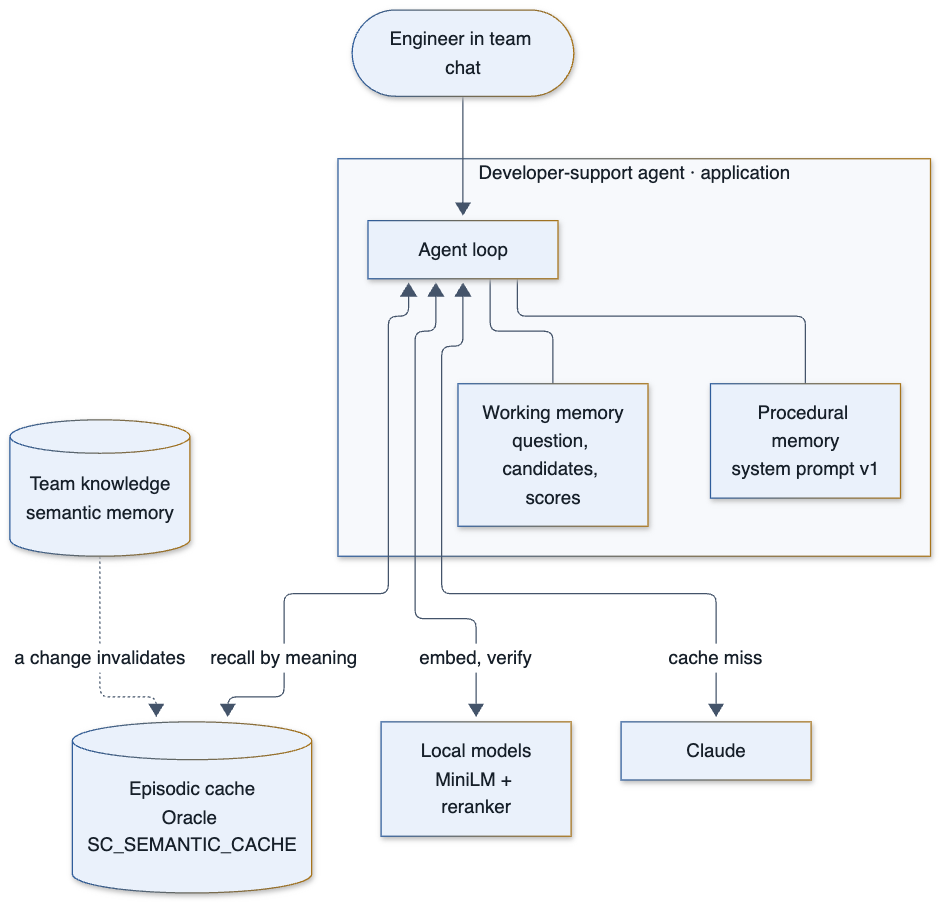

<details><summary>Mermaid source</summary>

```mermaid
flowchart TB
    Eng([Engineer in team chat]) --> Loop
    subgraph App["Developer-support agent · application"]
        Loop[Agent loop] --- WM["Working memory<br/>question, candidates, scores"]
        Loop --- Proc["Procedural memory<br/>system prompt v1"]
    end
    Loop <-->|recall by meaning| Cache[("Episodic cache<br/>Oracle SC_SEMANTIC_CACHE")]
    Loop <-->|embed, verify| Models["Local models<br/>MiniLM + reranker"]
    Loop <-->|cache miss| Claude[Claude]
    Docs[("Team knowledge<br/>semantic memory")] -.->|a change invalidates| Cache
```

</details>

The agent loop reads and writes the episodic cache in Oracle, uses two local models to embed and
verify questions, and calls Claude only on a miss. The dotted edge is the obligation the cache
creates: when team knowledge changes, the answers built on it must be removed.

### Takeaways

- The use case is high-volume, paraphrase-heavy support traffic, where a semantic cache pays off.
- The cache is episodic memory recalled by meaning; it depends on, but never replaces, the
  knowledge and prompt behind the answers.
- Anything in the cache must be safe to lose and cheap to regenerate.

# Part 3 · Set up

## 3.1 · Imports and run settings

Standard-library modules handle hashing (`hashlib`), canonical JSON for cache scopes (`json`),
vector binding for Oracle (`array`) and the contrast guard's word matching (`re`).
`TOKENIZERS_PARALLELISM=false` silences a fork warning from the Hugging Face tokenizers library;
it must be set before the library is imported.

In [2]:
import array
import hashlib
import json
import os
import re
import time
import uuid
from getpass import getpass

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

'false'

Third-party packages: `numpy` and `pandas` for the measurements, `oracledb` (the thin driver, no
Oracle Client install needed), the raw `anthropic` SDK, and `sentence_transformers` for both local
models.

In [3]:
import numpy as np
import oracledb
import pandas as pd
from anthropic import Anthropic
from IPython.display import display
from sentence_transformers import CrossEncoder, SentenceTransformer

Three run-level settings:

- `RUN_ID` is a random id that goes into every cache namespace this notebook creates, so a re-run
  never sees rows from an earlier run and the cleanup at the end removes exactly this run's rows.
  In a real deployment you would leave it out of the namespace.
- `fetch_lobs = False` makes `oracledb` return `CLOB` columns (the cached answers) as Python strings
  instead of LOB locators that need a separate read.
- `MEASUREMENTS` collects one row per measured agent step.

In [4]:
RUN_ID = uuid.uuid4().hex[:12]
oracledb.defaults.fetch_lobs = False
MEASUREMENTS = []
print("Run id:", RUN_ID)

Run id: 27faaf0d5cf7


### Read private keys safely

`secret()` asks for a key with `getpass`, so the value is never echoed into the notebook
or saved with its outputs. Automated runs can set `NOTEBOOK_USE_ENV_KEYS=1` to read the
same name from an environment variable instead. An empty value stops the notebook early
with a clear error rather than failing later inside a provider call.

In [5]:
def secret(name):
    """Return a private key from a hidden prompt, or from the environment in automated runs."""
    if os.getenv("NOTEBOOK_USE_ENV_KEYS") == "1":
        value = os.getenv(name, "")
    else:
        value = getpass(f"Enter {name}: ")
    if not value.strip():
        raise ValueError(f"{name} is required.")
    return value.strip()

### Price every Claude call from reported usage

Every response from the Anthropic API reports how many tokens it processed. The prices below
are the published list prices for Claude Opus 5.5 (USD per million tokens, checked on
2026-10-03). Each counter is priced separately:

- `input`: ordinary prompt tokens.
- `cache_write`: prompt tokens written to Anthropic's prompt cache (1.25× input).
- `cache_read`: prompt tokens read back from that cache (0.05× input on Opus 5.5).
- `output`: generated tokens, the most expensive counter.

`LLM_CALLS` is a ledger: one row per real request, so every cost in this notebook can be
traced back to an actual API response. These are list-price estimates, not an invoice.

In [6]:
MODEL = "claude-opus-5-5"
PRICE = {"input": 4.00, "cache_write": 5.00, "cache_read": 0.20, "output": 20.00}
LLM_CALLS = []


def llm_cost(usage):
    """Price one response from the token counters the API returned."""
    tokens = {
        "input": usage.input_tokens,
        "cache_write": usage.cache_creation_input_tokens or 0,
        "cache_read": usage.cache_read_input_tokens or 0,
        "output": usage.output_tokens,
    }
    return tokens, sum(tokens[k] * PRICE[k] for k in tokens) / 1_000_000

### One function for every model call

`ask_claude()` sends a single request with the raw Anthropic SDK. `system` is either a plain
string or a list of content blocks (the list form is what lets a block carry a prompt-cache
breakpoint). `effort="low"` asks the model for a direct answer, which keeps latency and
output tokens down. The function records latency, the four token counters and the estimated
cost in `LLM_CALLS`, then returns only the visible text.

In [7]:
def ask_claude(system, user, max_tokens=1024):
    """Send one request, record latency, tokens and cost, and return the answer text."""
    started = time.perf_counter()
    response = claude.messages.create(
        model=MODEL,
        max_tokens=max_tokens,
        system=system,
        messages=[{"role": "user", "content": user}],
        output_config={"effort": "low"},
    )
    tokens, usd = llm_cost(response.usage)
    seconds = time.perf_counter() - started
    LLM_CALLS.append({"seconds": seconds, **tokens, "usd": usd})
    return "".join(b.text for b in response.content if b.type == "text")

Create the client. The key is read with `secret()`; the client object keeps it in memory
only. A timeout and two retries keep a slow network from hanging the notebook.

In [8]:
claude = Anthropic(api_key=secret("ANTHROPIC_API_KEY"), timeout=120, max_retries=2)

### Connect to Oracle AI Database

The cache tables live in a **dedicated application schema**. `oracle_connection()` reads
`ORACLE_USER`, `ORACLE_PASSWORD` and `ORACLE_DSN` from the environment and prompts for any
that are missing (the password prompt is hidden). It refuses `SYS` and `SYSTEM`: an
application cache should never run with administrator privileges. The schema needs
`CREATE TABLE` and a tablespace quota; vector features need Oracle AI Database 23ai or later.

In [9]:
def oracle_connection():
    """Connect to a dedicated schema; administrator accounts are refused."""
    user = os.getenv("ORACLE_USER") or input("Oracle user: ").strip()
    password = os.getenv("ORACLE_PASSWORD") or getpass("Oracle password: ")
    dsn = os.getenv("ORACLE_DSN") or input("Oracle DSN (host:port/service): ").strip()
    if user.lower() in {"sys", "system"}:
        raise ValueError("Use a dedicated application schema.")
    return oracledb.connect(user=user, password=password, dsn=dsn)


conn = oracle_connection()
print("Connected to Oracle", conn.version)

Connected to Oracle 23.26.2.0.0


`create_if_missing()` makes the DDL in this notebook safe to re-run. Oracle raises
`ORA-00955` when an object name already exists; only that error is ignored. Anything else,
such as a missing privilege or an exhausted vector memory pool, is raised so you can see it.

In [10]:
def create_if_missing(sql):
    """Run DDL, ignoring only 'name is already used by an existing object'."""
    with conn.cursor() as cursor:
        try:
            cursor.execute(sql)
        except oracledb.DatabaseError as error:
            if error.args[0].code != 955:
                raise

### Load the open-source embedding model

Embeddings come from [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), a small
open-source model from Hugging Face that runs locally on the CPU. It maps text to a
384-dimensional vector. Pinning the **revision** (a commit hash in the model repository)
matters for caching: if the model files change, the vectors change, and every stored vector
must be treated as stale. The first run downloads about 90 MB; later runs load from the
local Hugging Face cache. No API key is needed and no text leaves your machine.

In [11]:
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
EMBED_REVISION = "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"
encoder = SentenceTransformer(EMBED_MODEL, revision=EMBED_REVISION, device="cpu")
EMBED_DIM = encoder.get_embedding_dimension()
print(EMBED_MODEL, "→", EMBED_DIM, "dimensions")

sentence-transformers/all-MiniLM-L6-v2 → 384 dimensions


### Load the open-source reranker

A **reranker** is a cross-encoder: it reads two texts *together* and returns one relevance
score, which is slower than comparing two precomputed vectors but much better at telling
"same question" from "similar words". This notebook uses
[`cross-encoder/ms-marco-MiniLM-L-6-v2`](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2), also local and pinned to a
revision. Its scores are unbounded logits: higher means more relevant, and values above
zero mean the model leans towards "relevant".

In [12]:
RERANK_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
RERANK_REVISION = "233902d25c440f23af6f7d6e94d2946bac0bee0a"
reranker = CrossEncoder(RERANK_MODEL, revision=RERANK_REVISION, device="cpu")
print("Reranker ready:", RERANK_MODEL)

Reranker ready: cross-encoder/ms-marco-MiniLM-L-6-v2


## 3.2 · Load real developer questions

The `title-title-pair` subset of
[sentence-transformers/stackexchange-duplicates](https://huggingface.co/datasets/sentence-transformers/stackexchange-duplicates)
holds question titles from many StackExchange sites, two per row, where the community marked the
second as a duplicate of the first. pandas reads the Parquet file straight from Hugging Face. The
`@1c9657…` part of the path pins the dataset **revision**, so the rows are the same on every run.
Only the two title columns are read.

In [13]:
DUPLICATES = (
    "hf://datasets/sentence-transformers/stackexchange-duplicates"
    "@1c9657aec12d9e101667bb9593efcc623c4a68ff"
    "/title-title-pair/train-00000-of-00001.parquet"
)
pairs = pd.read_parquet(DUPLICATES, columns=["title1", "title2"])
print(f"{len(pairs):,} duplicate title pairs from all StackExchange sites")

304,525 duplicate title pairs from all StackExchange sites


The dataset spans every StackExchange site, from cooking to physics. A keyword rule keeps the pairs
where **both** titles name a programming language, tool or platform. The rule is crude (it misses
programming questions without a keyword and keeps a few off-topic ones), but it is transparent and
easy to change. `(?:...)` is a non-capturing group, which keeps pandas from warning about match
groups.

In [14]:
PROGRAMMING = (
    r"\b(?:python|java|javascript|sql|git|docker|pandas|numpy|regex|json|api|django"
    r"|react|node|bash|linux|c\+\+|c#|php|android|css|html)\b"
)
both = pairs.title1.str.contains(PROGRAMMING, case=False) & pairs.title2.str.contains(
    PROGRAMMING, case=False
)
dev_pairs = pairs[both].reset_index(drop=True)
print(f"{len(dev_pairs):,} pairs where both titles name a programming topic")

18,652 pairs where both titles name a programming topic


Popular questions are the target of many duplicates, so the same title appears in many rows. That
matters for the measurement in the next Part: to count a *false* hit, you need questions that are
known **not** to be marked as duplicates of each other. Keeping only pairs whose titles appear in no
other pair guarantees that two titles from different rows were never linked by the community. A few
may still ask the same thing without having been linked, which would count a harmless match as a
false hit. The false-hit rate below is therefore an estimate on this sample, not a guarantee: measure
it again on your own traffic.

**What to watch:** the sample rows should read like real engineers' questions, with the duplicate
in `title2` often phrased very differently from `title1`.

In [15]:
titles = pd.concat([dev_pairs.title1, dev_pairs.title2]).str.lower()
counts = titles.value_counts()
once = dev_pairs.title1.str.lower().map(counts).eq(1)
once &= dev_pairs.title2.str.lower().map(counts).eq(1)
clean_pairs = dev_pairs[once].reset_index(drop=True)
print(f"{len(clean_pairs):,} pairs whose titles appear in no other pair")
display(clean_pairs.sample(5, random_state=1))

6,965 pairs whose titles appear in no other pair


,title1,title2
5275,how to change the default time zone in just on...,Changing timezone in PHP
1653,How to send textarea who contains html using J...,Forbidden Error When Submitting Simple PHP Form
1954,Node js - Serving lots of files using Express,Setting up two different static directories in...
634,"In JavaScript, eval(010) returns 8",Number with leading zero in JavaScript
2263,How to import Tkinter in python 3.3.0,ImportError when importing Tkinter in Python


# Part 4 · Decide what "the same question" means

Before building the cache, measure how the two checks behave on real traffic. The acceptance
policy has two numbers: the largest cosine distance that still counts as close (`max_distance`),
and the smallest reranker score that still counts as the same question (`min_score`). Both are
chosen here from data.

## 4.1 · Encode questions

`embed()` is the only path from text to vectors in this notebook, used for calibration, for
storing and for lookups, which keeps every vector consistent. `normalize_embeddings=True` scales
each vector to length 1, so the dot product of two vectors *is* their cosine similarity and
`1 - dot` is their cosine distance. The result is `float32`, the same type as the
`VECTOR(384, FLOAT32)` column it will be stored in.

In [16]:
def embed(texts):
    """Encode texts as unit-length float32 vectors, one row per text."""
    vectors = encoder.encode(
        list(texts), normalize_embeddings=True, show_progress_bar=False
    )
    return np.asarray(vectors, dtype=np.float32)

## 4.2 · Measure duplicates and their closest impostors

Take 400 pairs (a fixed `random_state` makes the sample repeatable). Treat each `title1` as a
question the agent already answered and cached, and each `title2` as a new question arriving.
One matrix product compares every new question with every cached one: entry `[i, j]` is the cosine
similarity between new question *i* and cached question *j*. The diagonal holds the true duplicate
pairs.

In [17]:
sample = clean_pairs.sample(400, random_state=7).reset_index(drop=True)
cached_vectors = embed(sample.title1)  # questions the agent already answered
incoming_vectors = embed(sample.title2)  # new phrasings of the same questions
similarity = incoming_vectors @ cached_vectors.T
duplicate_distance = 1 - np.diag(similarity)
print(similarity.shape, "similarities computed")

(400, 400) similarities computed


For each new question, a wrong match is any cached question that is **not** its duplicate: an
*impostor*. The cache's `lookup()` (Part 5) checks the `CANDIDATES` nearest rows, closest first, and
serves the first one that passes, so a vetoed closest impostor can be followed by a second impostor that
passes. The measurement must check the same candidates. Blanking the diagonal with `-inf` removes the
true duplicate; `argsort` along each row then lists the closest impostors first. If the policy accepts
any of them, the cache would serve the wrong answer: that is a false hit.

In [18]:
CANDIDATES = 3  # rows lookup() checks per question, closest first
impostors = similarity.copy()
np.fill_diagonal(impostors, -np.inf)  # a question's own duplicate is not an impostor
impostor_index = np.argsort(-impostors, axis=1)[:, :CANDIDATES]
impostor_distance = 1 - np.take_along_axis(impostors, impostor_index, axis=1)
impostor_questions = sample.title1.iloc[
    impostor_index[:, 0]
].tolist()  # closest, for display

Now score both kinds of pair with the reranker. `predict()` takes `(new question, cached question)`
pairs and returns one score per pair. The order follows the reranker's training, where the first
text is the query. Scores are unbounded: positive leans "same question", negative leans
"different".

In [19]:
duplicate_pairs = list(zip(sample.title2, sample.title1))
impostor_pairs = [
    (new, sample.title1.iloc[j])
    for new, row in zip(sample.title2, impostor_index)
    for j in row
]
duplicate_score = reranker.predict(duplicate_pairs, show_progress_bar=False)
impostor_score = reranker.predict(impostor_pairs, show_progress_bar=False)
impostor_score = impostor_score.reshape(-1, CANDIDATES)  # one row per new question
print("Scored", len(duplicate_pairs) + len(impostor_pairs), "question pairs")

Scored 1600 question pairs


**What to watch:** the two distance distributions overlap. Many genuine duplicates are farther apart
than the impostors of other questions, because community duplicates are often phrased very
differently. No single distance separates them cleanly, which is why a threshold is a trade-off.

In [20]:
distances = pd.DataFrame(
    {"duplicate": duplicate_distance, "closest impostor": impostor_distance[:, 0]}
)
display(distances.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T.round(3))

,count,mean,std,min,10%,25%,50%,75%,90%,max
duplicate,400.0,0.322,0.170,0.006,0.118,0.203,0.302,0.421,0.56,0.891
closest impostor,400.0,0.506,0.102,0.155,0.372,0.445,0.512,0.572,0.64,0.827


## 4.3 · Compare acceptance policies

`policy_rates()` applies one candidate policy to all 400 new questions and returns two rates:

- **duplicate recall**: the share of genuine duplicates the cache would serve from memory (higher
  saves more LLM calls);
- **false hits**: the share of new questions for which **any** of their `CANDIDATES` closest impostors
  would be accepted, exactly as `lookup()` would, meaning the cache would serve another question's
  answer (lower is safer).

`min_score=None` turns the reranker check off, so the first policy family uses distance alone.

In [21]:
def policy_rates(max_distance, min_score=None):
    """Return (duplicate recall, false-hit rate) for one acceptance policy."""
    accept_duplicate = duplicate_distance <= max_distance
    accept_impostor = impostor_distance <= max_distance  # one column per candidate
    if min_score is not None:
        accept_duplicate &= duplicate_score >= min_score
        accept_impostor &= impostor_score >= min_score
    return accept_duplicate.mean(), accept_impostor.any(axis=1).mean()

Evaluate a grid: five distance limits, each with the reranker check off, at score ≥ 0 and at
score ≥ 2.

**What to watch:** with distance alone, recall and false hits rise together as the limit loosens.
Adding the reranker check removes most of the impostors at the looser limits while keeping many of
the duplicates, so the same false-hit level allows a looser distance and a higher recall.

In [22]:
rows = []
for max_distance in [0.15, 0.20, 0.25, 0.30, 0.35]:
    for min_score in [None, 0.0, 2.0]:
        check = "off" if min_score is None else f"score >= {min_score:g}"
        rows.append(
            (max_distance, check, min_score, *policy_rates(max_distance, min_score))
        )
columns = ["max_distance", "reranker", "min_score", "duplicate_recall", "false_hits"]
policies = pd.DataFrame(rows, columns=columns)
view = policies.pivot(index="max_distance", columns="reranker")
display(view[["duplicate_recall", "false_hits"]].round(3))

duplicate_recall                       false_hits             \
reranker                  off score >= 0 score >= 2        off score >= 0   
max_distance                                                                
0.15                    0.155      0.155      0.152      0.000      0.000   
0.20                    0.240      0.230      0.218      0.008      0.008   
0.25                    0.372      0.332      0.280      0.012      0.010   
0.30                    0.495      0.412      0.328      0.038      0.025   
0.35                    0.598      0.460      0.355      0.072      0.028   

                         
reranker     score >= 2  
max_distance             
0.15              0.000  
0.20              0.002  
0.25              0.005  
0.30              0.015  
0.35              0.018

## 4.4 · Choose the policy

Decide the risk first, then maximise savings within it. `FALSE_HIT_BUDGET = 0.03` says: at most 3
in 100 new questions may be offered another question's answer. The cell keeps the policies within
that budget and picks the one with the highest duplicate recall.

`POLICY` is the single place the cache reads its thresholds from. A missing reranker check becomes
`-inf`, a score every pair passes, so the lookup code needs no special case. `contrast_guard`
starts off; Part 6 shows why it exists.

**What to watch:** the chosen policy uses the reranker check together with a looser distance limit.

In [23]:
FALSE_HIT_BUDGET = 0.03
affordable = policies[policies.false_hits <= FALSE_HIT_BUDGET]
best = affordable.sort_values("duplicate_recall").iloc[-1]
min_score = -np.inf if pd.isna(best.min_score) else float(best.min_score)
POLICY = dict(max_distance=float(best.max_distance), min_score=min_score)
POLICY["contrast_guard"] = False
print("Chosen policy:", POLICY)
print(f"recall {best.duplicate_recall:.1%}, false hits {best.false_hits:.1%}")

Chosen policy: {'max_distance': 0.35, 'min_score': 0.0, 'contrast_guard': False}
recall 46.0%, false hits 2.8%


For comparison, the best policy within the same budget that uses distance alone.

**What to watch:** to stay within budget without the reranker, the distance limit must be tighter,
and duplicate recall is lower than with the chosen policy.

In [24]:
distance_only = affordable[affordable.min_score.isna()]
distance_only = distance_only.sort_values("duplicate_recall").iloc[-1]
print("Distance only: max_distance", distance_only.max_distance)
print(
    f"recall {distance_only.duplicate_recall:.1%}, false hits {distance_only.false_hits:.1%}"
)

Distance only: max_distance 0.25
recall 37.2%, false hits 1.2%


## 4.5 · Look at what the policy rejects

Numbers hide what the checks actually do. The first table lists impostors that are **within** the
distance limit but **vetoed** by the reranker: close in vector space, different questions. The
second lists genuine duplicates the policy **misses**: the price of keeping false hits low.

**What to watch:** the vetoed impostors share a topic with their cached question but differ in
platform, library or intent. The missed duplicates are often phrased so differently that only
someone who knows both answers would link them.

In [25]:
near = pd.DataFrame(
    {
        "new question": sample.title2,
        "closest impostor": impostor_questions,
        "distance": impostor_distance[:, 0],
        "score": impostor_score[:, 0],
    }
)
vetoed = near[
    (near.distance <= POLICY["max_distance"]) & (near.score < POLICY["min_score"])
]
display(vetoed.sort_values("distance").head(5).round(3))

,new question,closest impostor,distance,score
205,python regular expression replacing part of a ...,python .replace() regex,0.177,-2.504
58,Generating HTML email body in C#,How can i send an e-mail with HTML content,0.243,-10.093
341,Python command within script to abort without ...,When cancelling a Python script do something,0.262,-6.868
1,Java Timer,how to use an android timer,0.267,-5.936
334,Using jQuery to trigger html onclick event,Function doesn't execute from an onclick insid...,0.277,-2.606


And five genuine duplicates the policy would not serve from the cache, either because they are
too far apart in vector space or because the reranker scores them below the minimum.

In [26]:
pairs_view = pd.DataFrame(
    {
        "cached question": sample.title1,
        "duplicate": sample.title2,
        "distance": duplicate_distance,
        "score": duplicate_score,
    }
)
accepted = (pairs_view.distance <= POLICY["max_distance"]) & (
    pairs_view.score >= POLICY["min_score"]
)
display(pairs_view[~accepted].sample(5, random_state=3).round(3))

,cached question,duplicate,distance,score
121,Change all metallic value with python,Changing a value node in many materials with a...,0.416,1.200
47,Python: Test server availability without using...,How do you send a HEAD HTTP request in Python 2?,0.644,-8.627
232,What is the maximum possible length/size of a ...,Is there a limit on how much JSON can hold?,0.315,-1.059
201,"HTML, PHP and javascript","If HTML, CSS, and Javascript are client-side, ...",0.299,-1.135
277,Can we convert a black and white image to reve...,Invert colors of an image in CSS or JavaScript,0.324,-0.036


These thresholds come from short StackExchange titles. Real support messages are longer and carry
more context, so measure again on your own traffic before relying on any number here.

### Takeaways

- Threshold choice is a recall/false-hit trade-off; measure both on real pairs before choosing.
- Fix the false-hit budget first, then take the highest recall that fits it.
- The reranker earns its place by allowing a looser distance limit at the same risk.
- Many genuine paraphrases will still miss; a semantic cache saves a share of calls, not all.

# Part 5 · Build the semantic cache in Oracle

## 5.1 · The cache table

One row per cached answer:

- `cache_id`: a hash of namespace and question text, so storing the same question twice updates
  one row instead of adding another;
- `namespace`: the scope hash from the next cells; every lookup filters on it;
- `question`: the original wording, kept for verification and for auditing hits;
- `answer`: a `CLOB`, because answers can exceed the 4,000-byte `VARCHAR2` limit;
- `embedding`: a `VECTOR(384, FLOAT32)`, sized to the model; Oracle rejects a vector with any other
  dimension count, which catches a model swap early;
- `created_at` and `expires_at`: timestamps with time zone, set by the database clock.

`create_if_missing()` (defined in Set up) makes the cell safe to re-run.

In [27]:
create_if_missing(f"""
    CREATE TABLE SC_SEMANTIC_CACHE (
        cache_id   VARCHAR2(64) PRIMARY KEY,
        namespace  VARCHAR2(64) NOT NULL,
        question   VARCHAR2(4000) NOT NULL,
        answer     CLOB NOT NULL,
        embedding  VECTOR({EMBED_DIM}, FLOAT32) NOT NULL,
        created_at TIMESTAMP WITH TIME ZONE DEFAULT SYSTIMESTAMP NOT NULL,
        expires_at TIMESTAMP WITH TIME ZONE NOT NULL
    )""")
print("SC_SEMANTIC_CACHE is ready")

SC_SEMANTIC_CACHE is ready


## 5.2 · The HNSW vector index

Without an index, a nearest-neighbour query compares the question with every row. An **HNSW**
(Hierarchical Navigable Small World) index is a layered graph that links each vector to near
neighbours, so a search can hop towards the query and inspect only a small part of the table. The
answer is *approximate*: it can occasionally miss the true nearest row, in exchange for speed that
holds as the cache grows. Each clause:

- `ORGANIZATION INMEMORY NEIGHBOR GRAPH`: the graph lives in the database's vector memory pool
  (part of the SGA), which must be sized by the DBA (`VECTOR_MEMORY_SIZE`).
- `DISTANCE COSINE`: the metric the graph is built for. Queries must use the same metric, or the
  index cannot serve them.
- `WITH TARGET ACCURACY 95`: the default search effort, aiming to return 95% of the true nearest
  neighbours.
- `NEIGHBORS 32`: the maximum links per vector in each layer; more links give better recall and use
  more memory.
- `EFCONSTRUCTION 128`: how many candidates are considered when inserting a vector; higher builds a
  better graph more slowly.

Rows inserted after the index is built are still found: Oracle tracks them in a journal next to the
graph until the graph is refreshed.

In [28]:
create_if_missing("""
    CREATE VECTOR INDEX SC_SEMANTIC_HNSW ON SC_SEMANTIC_CACHE (embedding)
    ORGANIZATION INMEMORY NEIGHBOR GRAPH
    DISTANCE COSINE
    WITH TARGET ACCURACY 95
    PARAMETERS (TYPE HNSW, NEIGHBORS 32, EFCONSTRUCTION 128)""")
print("SC_SEMANTIC_HNSW is ready")

SC_SEMANTIC_HNSW is ready


## 5.3 · The namespace

`namespace_for()` turns the scope into one fixed-length key. `json.dumps(..., sort_keys=True)` gives
the same text for the same scope regardless of dictionary order, and SHA-256 turns that text into a
64-character hex string that fits the `namespace` column. Change any part (tenant, model, prompt
version, embedding model or revision) and the namespace changes, so old rows stop matching. That
is invalidation by configuration, with no delete needed. `RUN_ID` keeps this notebook's rows apart
from earlier runs.

In [29]:
PROMPT_VERSION = "support-answer-v1"


def namespace_for(tenant):
    """Hash everything that must match before two answers are interchangeable."""
    scope = {
        "tenant": tenant,
        "model": MODEL,
        "prompt": PROMPT_VERSION,
        "embedder": f"{EMBED_MODEL}@{EMBED_REVISION}",
        "run": RUN_ID,
    }
    return hashlib.sha256(json.dumps(scope, sort_keys=True).encode()).hexdigest()

## 5.4 · Nearest-neighbour search

The query in plain words: *among rows in this namespace that have not expired, return the `k`
whose embedding is closest to the query vector, closest first, using the approximate index.*

- `VECTOR_DISTANCE(embedding, :query_vector, COSINE)` computes the cosine distance for each
  candidate row.
- `FETCH APPROX FIRST :k ROWS ONLY` asks for an approximate top-k, which allows the HNSW index;
  `FETCH FIRST` without `APPROX` would demand an exact answer.
- The hint `VECTOR_INDEX_SCAN` asks the optimizer to use the vector index even while the table is
  tiny and a full scan would look cheaper, so the plan below is the one a large cache would get.
- Only `cache_id`, the matched question and the distance come back. The answer `CLOB` is read later
  and only for a verified hit, so misses never transfer answer text.

In [30]:
NEAREST_SQL = """
    SELECT /*+ VECTOR_INDEX_SCAN(SC_SEMANTIC_CACHE SC_SEMANTIC_HNSW) */
           cache_id, question AS matched,
           VECTOR_DISTANCE(embedding, :query_vector, COSINE) AS distance
    FROM SC_SEMANTIC_CACHE
    WHERE namespace = :namespace AND expires_at > SYSTIMESTAMP
    ORDER BY distance
    FETCH APPROX FIRST :k ROWS ONLY WITH TARGET ACCURACY 95"""

`nearest()` runs that query. `array.array("f", vector)` binds the numpy vector as 32-bit floats,
which `oracledb` sends as a `VECTOR`. Each row comes back as a dictionary keyed by lower-case column
name. `k=CANDIDATES` returns the same three candidates the calibration measured, so a vetoed closest
match can still be followed by a verified second one.

In [31]:
def nearest(vector, namespace, k=CANDIDATES):
    """Return up to k live cached questions in this namespace, closest first."""
    with conn.cursor() as cursor:
        cursor.execute(
            NEAREST_SQL, query_vector=array.array("f", vector), namespace=namespace, k=k
        )
        columns = [d[0].lower() for d in cursor.description]
        return [dict(zip(columns, row)) for row in cursor]

## 5.5 · Check that Oracle uses the index

`EXPLAIN PLAN` asks the optimizer how it would run the search, without running it, and
`DBMS_XPLAN.DISPLAY` prints the plan.

**What to watch:** a `VECTOR INDEX HNSW SCAN` step on `SC_SEMANTIC_HNSW`. `IN-FILTER` means the
namespace and expiry conditions are applied *while* walking the graph, so rows from other tenants
are skipped during the search instead of being found and thrown away afterwards.

In [32]:
probe = embed(["how to use an android timer"])[0]
with conn.cursor() as cursor:
    cursor.execute(
        "EXPLAIN PLAN FOR " + NEAREST_SQL,
        query_vector=array.array("f", probe),
        namespace="plan-check",
        k=3,
    )
    cursor.execute(
        "SELECT plan_table_output FROM TABLE(DBMS_XPLAN.DISPLAY(format => 'BASIC'))"
    )
    print("\n".join(row[0] for row in cursor))

Plan hash value: 605422960
 
-----------------------------------------------------------------
| Id  | Operation                           | Name              |
-----------------------------------------------------------------
|   0 | SELECT STATEMENT                    |                   |
|   1 |  COUNT STOPKEY                      |                   |
|   2 |   VIEW                              |                   |
|   3 |    SORT ORDER BY STOPKEY            |                   |
|   4 |     VECTOR INDEX HNSW SCAN IN-FILTER| SC_SEMANTIC_HNSW  |
|   5 |      VIEW                           | VW_HIF_5824671A   |
|   6 |       TABLE ACCESS BY USER ROWID    | SC_SEMANTIC_CACHE |
-----------------------------------------------------------------


## 5.6 · Verify a candidate with the reranker

`verify()` scores one `(new question, cached question)` pair with the cross-encoder. It runs only on
candidates that already passed the distance check, so the slower model sees a handful of pairs per
request, never the whole table.

In [33]:
def verify(question, cached_question):
    """Score a question pair with the cross-encoder; higher means more likely the same."""
    pair = [(question, cached_question)]
    return float(reranker.predict(pair, show_progress_bar=False)[0])

## 5.7 · A contrast guard

Both models can be fooled by questions that differ by one opposing word. `contrast_conflict()` is a
deliberately simple rule: if one question uses a word and the other uses its opposite (advantage
against disadvantage, enable against disable, and so on), the pair is not the same question. `\b`
anchors each word at a word boundary, so `advantage` does not match inside `disadvantage`. The
guard stays off until Part 6 shows the failure it addresses.

In [34]:
CONTRASTS = [
    ("advantage", "disadvantage"),
    ("enable", "disable"),
    ("install", "uninstall"),
]


def mentions(text, word):
    return re.search(rf"\b{word}", text, re.I) is not None


def contrast_conflict(question, cached_question):
    """True when one question uses a word and the other uses its opposite."""
    for word, opposite in CONTRASTS:
        a = (mentions(question, word), mentions(question, opposite))
        b = (mentions(cached_question, word), mentions(cached_question, opposite))
        if a != b and any(a) and any(b):
            return True
    return False

## 5.8 · Apply the policy to one candidate

`check_candidate()` is the acceptance policy in code, cheapest test first: the distance (already
computed by Oracle), then the optional contrast guard (a few regular expressions), then the reranker
(a model pass). It returns whether the candidate is accepted, the reason, and the reranker score
when one was computed.

In [35]:
def check_candidate(question, row):
    """Apply POLICY to one candidate row; return (accepted, reason, rerank score)."""
    if row["distance"] > POLICY["max_distance"]:
        return False, "too far: distance check", None
    if POLICY["contrast_guard"] and contrast_conflict(question, row["matched"]):
        return False, "contrast guard", None
    score = verify(question, row["matched"])
    if score < POLICY["min_score"]:
        return False, "vetoed: reranker check", score
    return True, "verified hit", score

## 5.9 · The lookup decision

`lookup()` ties the pieces together and returns a **decision** dictionary rather than just an
answer, so every step of the agent can report *why* it hit or missed. It embeds the question,
fetches up to three candidates and checks them closest first:

- the decision reports the closest candidate (or a later one that passes);
- the first accepted candidate wins, and only then is its answer read from Oracle;
- a candidate that fails the distance check ends the loop, because every later row is farther still;
- with no candidates at all, the reason is "no live entry in scope".

The vector is returned in the decision so a miss can store the new answer without embedding the
question a second time.

In [36]:
def cached_answer(cache_id):
    """Read one cached answer only after its question passed every check."""
    with conn.cursor() as cursor:
        cursor.execute(
            "SELECT answer FROM SC_SEMANTIC_CACHE WHERE cache_id = :id", id=cache_id
        )
        return cursor.fetchone()[0]

`lookup()` itself. `enumerate` numbers the candidates so the closest one (`rank == 0`) is always
reported. `check_candidate()` writes its reason and score straight into the candidate row, and
`decision.update(row)` copies the row's `cache_id`, `matched`, `distance`, `reason` and `score`
into the decision.

In [37]:
def lookup(question, namespace):
    """Embed, search Oracle, check candidates closest-first; return the decision."""
    vector = embed([question])[0]
    decision = {"hit": False, "reason": "no live entry in scope", "vector": vector}
    for rank, row in enumerate(nearest(vector, namespace)):
        accepted, row["reason"], row["score"] = check_candidate(question, row)
        if accepted or rank == 0:  # report the closest row unless a later one passes
            decision.update(row)
        if accepted:
            return {**decision, "hit": True, "answer": cached_answer(row["cache_id"])}
        if row["reason"].startswith("too far"):
            break  # rows are sorted by distance, so the rest are farther still
    return decision

## 5.10 · Store an answer

The `MERGE` statement in plain words: *if a row with this `cache_id` exists, replace its answer,
vector and expiry; otherwise insert a new row.* A retry refreshes the same row. Two workers that store
the same new question at the same moment both take the insert branch, because neither sees the other's
uncommitted row: the primary key lets one in, and the second fails with `ORA-00001` once the first
commits. `merge_once()` below treats that error as success, since the row it wanted now exists.

Every value is bound exactly once, inside the `USING (SELECT ... FROM dual)` source row, and the
`UPDATE` and `INSERT` branches refer to it as `s.<column>`. `SYSTIMESTAMP + NUMTODSINTERVAL(:ttl,
'SECOND')` computes the expiry with the database clock, so every agent worker agrees on when a row
expires, whatever its own clock says.

In [38]:
STORE_SQL = """
    MERGE INTO SC_SEMANTIC_CACHE t
    USING (SELECT :cache_id AS cache_id, :namespace AS namespace, :question AS question,
                  :answer AS answer, :embedding AS embedding,
                  SYSTIMESTAMP + NUMTODSINTERVAL(:ttl, 'SECOND') AS expires_at
           FROM dual) s
    ON (t.cache_id = s.cache_id)
    WHEN MATCHED THEN UPDATE SET
        t.answer = s.answer, t.embedding = s.embedding, t.expires_at = s.expires_at
    WHEN NOT MATCHED THEN INSERT (cache_id, namespace, question, answer, embedding, expires_at)
        VALUES (s.cache_id, s.namespace, s.question, s.answer, s.embedding, s.expires_at)"""

`merge_once()` runs one upsert and absorbs exactly one error: `ORA-00001` (error code 1), the unique-key
violation a worker gets when another worker inserted the same key first. The row it wanted to store
already exists, so that is success. Any other database error is raised.

In [39]:
def merge_once(cursor, sql, binds):
    """Run an upsert MERGE; if another worker inserted the same key first, its row stands."""
    try:
        cursor.execute(sql, binds)
    except oracledb.IntegrityError as error:
        if error.args[0].code != 1:  # anything other than ORA-00001 is a real failure
            raise

`store()` derives the `cache_id` from namespace and question, declares the answer bind as a `CLOB`
(`setinputsizes`) so answers longer than 4,000 bytes are accepted, runs the `MERGE` and commits.
`ttl_seconds` sets how long the answer may be served; ten minutes is the default here.

In [40]:
def store(question, answer, vector, namespace, ttl_seconds=600):
    """Insert or refresh one cached answer; the database clock sets its expiry."""
    cache_id = hashlib.sha256(f"{namespace}:{question}".encode()).hexdigest()
    binds = dict(
        cache_id=cache_id,
        namespace=namespace,
        question=question,
        answer=answer,
        embedding=array.array("f", vector),
        ttl=ttl_seconds,
    )
    with conn.cursor() as cursor:
        cursor.setinputsizes(answer=oracledb.DB_TYPE_CLOB)
        merge_once(cursor, STORE_SQL, binds)
    conn.commit()
    return cache_id

## 5.11 · The agent's answer function

The system prompt defines the support agent's behaviour: short answers with one code example. Its
wording is versioned by `PROMPT_VERSION`; if you edit it, bump the version so cached answers written
under the old prompt stop matching.

In [41]:
SYSTEM = (
    "You are a developer-support agent for a software team. Answer the engineer's "
    "programming question in at most 120 words. Include one short code example when it "
    "helps. If the question is ambiguous, state the assumption you made."
)

`answer()` is the whole cache-aside pattern: look up first; on a verified hit return the stored
answer; on a miss call Claude, store the new answer with the vector the lookup already computed, and
return it. The tenant defaults to `platform-team`, the team that runs this agent.

In [42]:
def answer(question, tenant="platform-team", ttl_seconds=600):
    """Serve a verified cached answer, or ask Claude and cache the new answer."""
    namespace = namespace_for(tenant)
    decision = lookup(question, namespace)
    if decision["hit"]:
        return decision
    decision["answer"] = ask_claude(SYSTEM, question, max_tokens=500)
    store(question, decision["answer"], decision["vector"], namespace, ttl_seconds)
    return decision

## 5.12 · Measure every step

`record()` runs one agent step, times it with a monotonic clock, and counts the Claude calls the
step made by comparing the length of `LLM_CALLS` before and after. It also sums the time spent
inside those calls (`llm_seconds`), so the cache's own overhead can be separated from the LLM's
latency, which varies from call to call. It appends one row to
`MEASUREMENTS` with the decision fields (`DECISION_FIELDS` maps each decision key to its column
name), so the final table shows latency, the cache decision and cost side by side. `show()` prints a
step's decision and the start of its answer.

In [43]:
DECISION_FIELDS = dict(
    hit="cache_hit", reason="reason", distance="distance", score="rerank_score"
)


def record(step, question, work):
    """Run one agent step and append its latency, decision and cost to MEASUREMENTS."""
    mark, started = len(LLM_CALLS), time.perf_counter()
    result = work()
    seconds = round(time.perf_counter() - started, 3)
    row = {"step": step, "question": question, "seconds": seconds}
    row.update({column: result.get(key) for key, column in DECISION_FIELDS.items()})
    calls = LLM_CALLS[mark:]
    row["llm_calls"], row["llm_seconds"] = len(calls), sum(c["seconds"] for c in calls)
    row["estimated_usd"] = sum(c["usd"] for c in calls)
    MEASUREMENTS.append(row)
    return result

`show()` prints the decision fields as an aligned two-column list, then up to `chars` characters of
the answer, enough to recognise which question it answers.

In [44]:
def show(result, chars=350):
    """Print the cache decision and the first characters of the answer, if any."""
    fields = ["hit", "reason", "matched", "distance", "score"]
    print(pd.Series({f: result.get(f) for f in fields}).to_string())
    if result.get("answer"):
        print("\n" + result["answer"][:chars])

### Takeaways

- The cache is one table, one HNSW index and two SQL statements: a filtered approximate top-k, and
  a `MERGE` upsert that tolerates a concurrent first write (`ORA-00001`).
- Scope is enforced in SQL (`namespace`, `expires_at`) before any similarity is considered.
- The policy runs cheapest check first; the reranker sees only a few candidates per request.
- Every lookup returns a decision with its reason, which makes hits and misses auditable.

# Part 6 · Run the agent with and without the cache

The cached question is a real title from the dataset, and its paraphrase is the duplicate the
StackExchange community linked to it. Both are read from the data rather than typed, and the cell
checks they are there.

In [45]:
QUESTION = "how to use an android timer"
DUPLICATE = clean_pairs.loc[clean_pairs.title1 == QUESTION, "title2"].iloc[0]
print("Cached question:", QUESTION)
print("Its duplicate:  ", DUPLICATE)

Cached question: how to use an android timer
Its duplicate:   How to set timer in android?


## 6.1 · Baseline: no cache

Without a cache, every question is a Claude call. This is the latency and cost the cache tries to
remove.

**What to watch:** several seconds of latency, one LLM call and a non-zero estimated cost.

In [46]:
def no_cache():
    reply = ask_claude(SYSTEM, QUESTION, max_tokens=500)
    return {"answer": reply, "hit": False, "reason": "no cache"}


baseline = record("baseline: no cache", QUESTION, no_cache)
print(baseline["answer"][:350])

**Assumption:** You want a countdown or periodic tick that updates the UI, written in Kotlin. Android's built-in `CountDownTimer` handles this and runs its callbacks on the main thread.

```kotlin
val timer = object : CountDownTimer(30_000, 1_000) { // total, interval (ms)
    override fun onTick(msLeft: Long) {
        textView.text = "${msLeft / 


## 6.2 · Cold: the first question misses

The cache is empty for this namespace, so the lookup finds nothing, Claude answers, and the answer
is stored.

**What to watch:** `hit` is `False` with reason "no live entry in scope". The step takes roughly as
long as the baseline: it makes the same Claude call, plus milliseconds of embedding, searching and
storing (Part 7 separates the two).

In [47]:
cold = record("cold: first ask", QUESTION, lambda: answer(QUESTION))
show(cold)

hit                          False
reason      no live entry in scope
matched                       None
distance                      None
score                         None

**Assumption:** You want to run code repeatedly (e.g., every second) and update the UI. Kotlin is shown.

Avoid `java.util.Timer` for UI work because it runs on a background thread. Use a `Handler` instead:

```kotlin
private val handler = Handler(Looper.getMainLooper())
private val tick = object : Runnable {
    override fun run() {
        textVi


## 6.3 · Warm: the same question hits

The identical question now finds its own row at a distance of (almost exactly) zero, passes the
reranker, and the stored answer comes back.

**What to watch:** `hit` is `True`, the distance is near 0, no LLM call is made, the latency drops from
seconds to a fraction of a second, and the answer is identical to the cold one.

In [48]:
warm = record("warm: same question", QUESTION, lambda: answer(QUESTION))
show(warm, chars=120)
assert warm["hit"] and warm["answer"] == cold["answer"]

hit                                True
reason                     verified hit
matched     how to use an android timer
distance                            0.0
score                          4.962853

**Assumption:** You want to run code repeatedly (e.g., every second) and update the UI. Kotlin is shown.

Avoid `java.ut


## 6.4 · A real duplicate

This is the case a semantic cache exists for: a different engineer asks the same question in other
words. The result is whatever the policy decides; the decision fields show the distance and the
reranker score that produced it.

**What to watch:** with the policy chosen above, this paraphrase is close in vector space and
scores positively with the reranker, so it is served from the cache with no LLM call.

In [49]:
duplicate = record("real duplicate", DUPLICATE, lambda: answer(DUPLICATE))
show(duplicate, chars=120)

hit                                True
reason                     verified hit
matched     how to use an android timer
distance                        0.05864
score                          3.161537

**Assumption:** You want to run code repeatedly (e.g., every second) and update the UI. Kotlin is shown.

Avoid `java.ut


## 6.5 · Cases that must miss

The next steps run only the **lookup**, because the point is the decision. A miss in production
would continue exactly like the cold request above: one Claude call, then a store. Each `record()`
row is labelled "(lookup)" so the table does not mistake these for complete agent turns.

**A look-alike.** "How to set a Timer in Java?" is another title from the dataset. It shares
nearly every word with the cached Android question, but the right answer uses a different API.

**What to watch:** the distance is *within* the limit, so the distance check alone would serve the
Android answer; the reranker score is negative and the reason is "vetoed: reranker check".

In [50]:
LOOK_ALIKE = "How to set a Timer in Java?"
assert LOOK_ALIKE in set(clean_pairs.title1) | set(clean_pairs.title2)
team = namespace_for("platform-team")
lookalike = record("look-alike (lookup)", LOOK_ALIKE, lambda: lookup(LOOK_ALIKE, team))
show(lookalike)

hit                               False
reason           vetoed: reranker check
matched     how to use an android timer
distance                       0.229493
score                         -4.522931


**An unrelated question.** A question about a different topic should be rejected by the cheapest
check.

**What to watch:** a large distance and the reason "too far: distance check"; the reranker never runs
(`score` is `None`).

In [51]:
UNRELATED = "How do I write a Python dictionary to a csv file?"
unrelated = record("unrelated (lookup)", UNRELATED, lambda: lookup(UNRELATED, team))
show(unrelated)

hit                               False
reason          too far: distance check
matched     how to use an android timer
distance                        0.96685
score                              None


**Another tenant.** The payments team asks the exact question the platform team cached. Their
namespace differs, so the SQL filter excludes the platform team's row before any distance is
computed.

**What to watch:** reason "no live entry in scope", even though the text is identical.

In [52]:
payments = namespace_for("payments-team")
other = record("other tenant (lookup)", QUESTION, lambda: lookup(QUESTION, payments))
show(other)

hit                          False
reason      no live entry in scope
matched                       None
distance                      None
score                         None


**Expiry.** Store the cold answer again under a separate scope with a three-second time-to-live,
look it up straight away, wait four seconds and look again. No Claude call is needed: the answer
and vector from the cold step are reused.

**What to watch:** the first lookup is a "verified hit"; the second returns "no live entry in scope",
because `expires_at > SYSTIMESTAMP` now excludes the row.

In [53]:
short_scope = namespace_for("expiry-check")
store(QUESTION, cold["answer"], cold["vector"], short_scope, ttl_seconds=3)
fresh = record(
    "expiry: just stored (lookup)", QUESTION, lambda: lookup(QUESTION, short_scope)
)
time.sleep(4)
expired = record(
    "expiry: 4 s later (lookup)", QUESTION, lambda: lookup(QUESTION, short_scope)
)
print(fresh["reason"], "→", expired["reason"])

verified hit → no live entry in scope


## 6.6 · When both checks are wrong

Some pairs defeat both models. Ask about the advantages of Docker (a miss, so Claude answers and the
answer is stored), then ask about the disadvantages.

**What to watch:** the second question is a **hit**: a tiny distance and a positive reranker score.
The answer served is the one written about *advantages*. This is a false hit, the failure mode the
false-hit budget exists for.

In [54]:
ADVANTAGES = "What are the advantages of Docker?"
DISADVANTAGES = "What are the disadvantages of Docker?"
first = record("contrast: advantages", ADVANTAGES, lambda: answer(ADVANTAGES))
wrong = record("contrast: disadvantages", DISADVANTAGES, lambda: answer(DISADVANTAGES))
show(wrong)

hit                                       True
reason                            verified hit
matched     What are the advantages of Docker?
distance                              0.063904
score                                 2.684529

**Assumption:** You mean Docker containers for building and deploying applications.

**Key advantages:**

- **Consistency:** The same image runs identically on laptops, CI, and production, which avoids "works on my machine" problems.
- **Isolation:** Each app gets its own dependencies, with no version conflicts.
- **Lightweight:** Containers share 


Turn on the contrast guard and look the same question up again.

**What to watch:** the closest candidate is still the advantages question, now rejected with the
reason "contrast guard", so the agent would generate a fresh answer.

In [55]:
POLICY["contrast_guard"] = True
guarded = record(
    "contrast + guard (lookup)", DISADVANTAGES, lambda: lookup(DISADVANTAGES, team)
)
show(guarded)

hit                                      False
reason                          contrast guard
matched     What are the advantages of Docker?
distance                              0.063904
score                                     None


A word list only catches the contrasts someone thought to write down. "Java" against "Android",
"Python 2" against "Python 3" or "before" against "after" would each need their own rule. Stronger
mitigations, roughly in order of cost:

- **Narrow the scope** further, for example by product area, so fewer near-misses compete.
- **Cache only stable, FAQ-style questions**, decided by a classifier or a rule before the lookup.
- **Tighten the policy** for high-stakes topics (security, data deletion) or skip the cache for them.
- **Review cached answers**: promote an answer to the cache only after a person approves it, and
  monitor which cached rows are served for which questions.

### Takeaways

- The same row serves an exact repeat and a genuine paraphrase with no LLM call.
- The reranker vetoes a look-alike that the distance check alone would have accepted.
- Scope and expiry are enforced by SQL, not by similarity.
- Some false hits pass both checks; guards, narrower scope and review limit the damage.

# Part 7 · Results, limits and production notes

## 7.1 · The measurements

One row per step. `cache_hit`, `reason`, `distance` and `rerank_score` come from the lookup
decision; `llm_calls`, `llm_seconds` and `estimated_usd` describe the Claude calls the step made.
`overhead_seconds` is everything else: embedding, reranking and database time.

**What to watch:** hits and lookups have zero LLM calls and a cost of zero; the baseline, cold and
"advantages" steps carry all of the cost. `overhead_seconds` stays in the milliseconds for every
step, misses included.

In [56]:
table = pd.DataFrame(MEASUREMENTS)
table["overhead_seconds"] = table.seconds - table.llm_seconds
display(table.drop(columns="question").round(4))

,step,seconds,cache_hit,reason,distance,rerank_score,llm_calls,llm_seconds,estimated_usd,overhead_seconds
0,baseline: no cache,4.738,False,no cache,NaN,NaN,1,4.7377,0.0088,0.0003
1,cold: first ask,5.453,False,no live entry in scope,NaN,NaN,1,5.1016,0.0089,0.3514
2,warm: same question,0.035,True,verified hit,0.0000,4.9629,0,0.0000,0.0000,0.0350
3,real duplicate,0.009,True,verified hit,0.0586,3.1615,0,0.0000,0.0000,0.0090
4,look-alike (lookup),0.009,False,vetoed: reranker check,0.2295,-4.5229,0,0.0000,0.0000,0.0090
5,unrelated (lookup),0.005,False,too far: distance check,0.9669,NaN,0,0.0000,0.0000,0.0050
6,other tenant (lookup),0.004,False,no live entry in scope,NaN,NaN,0,0.0000,0.0000,0.0040
7,expiry: just stored (lookup),0.008,True,verified hit,0.0000,4.9629,0,0.0000,0.0000,0.0080
8,expiry: 4 s later (lookup),0.020,False,no live entry in scope,NaN,NaN,0,0.0000,0.0000,0.0200
9,contrast: advantages,5.580,False,too far: distance check,0.9468,NaN,1,5.4994,0.0079,0.0806


Compare the complete agent turns with the uncached baseline. A positive saving means the step was
faster or cheaper than calling Claude directly. The cold step makes the same Claude call as the
baseline, so its difference from the baseline is mostly LLM response-time variance; its real cost
is the overhead printed on the last line.

**What to watch:** the warm and duplicate steps save nearly the whole baseline latency and cost; the
miss overhead is a small fraction of a second, far below the time of the Claude call.

In [57]:
steps = table.set_index("step")
base = steps.loc["baseline: no cache"]
for step in ["cold: first ask", "warm: same question", "real duplicate"]:
    row = steps.loc[step]
    saved_s = base.seconds - row.seconds
    saved_usd = base.estimated_usd - row.estimated_usd
    print(
        f"{step:22} {row.seconds:7.3f} s   saved {saved_s:+7.3f} s   {saved_usd:+.5f} USD"
    )
overhead_ms = 1000 * steps.loc["cold: first ask", "overhead_seconds"]
print(f"Cache overhead on the cold miss: {overhead_ms:.0f} ms")

cold: first ask          5.453 s   saved  -0.715 s   -0.00008 USD
warm: same question      0.035 s   saved  +4.703 s   +0.00879 USD
real duplicate           0.009 s   saved  +4.729 s   +0.00879 USD
Cache overhead on the cold miss: 351 ms


## 7.2 · Reading the numbers

- **Hits** cost one embedding, one indexed query, one reranker pass and one `CLOB` read. All of it
  runs locally or in the database, so a hit costs no tokens and takes milliseconds.
- **Misses** pay that same overhead *plus* the full LLM call, so a miss is never faster than
  calling Claude directly; the cold row only looks different from the baseline because LLM response
  times vary between calls. With mostly unique traffic, the cache only adds latency.
- **Savings scale with the hit rate.** If a share *h* of requests hit, the expected saving per
  request is roughly *h* × (LLM latency and cost) minus the lookup overhead on every request. The
  recall measured in Part 4 is an estimate of *h* for paraphrases, not for all traffic.
- **A false hit has a cost these numbers do not show**: an engineer acting on the wrong answer.

## 7.3 · Production checklist

- **Measure thresholds on your own traffic**, per domain. Re-measure after changing the embedding
  model, the reranker or the kind of question the agent receives.
- **Monitor false hits**: log the matched question, distance and score for every hit, sample them
  for review, and track how often users rephrase or reject a cached answer.
- **Size the vector memory pool** (`VECTOR_MEMORY_SIZE`) for the HNSW graph: roughly the number of
  rows times the vector size, plus graph overhead. Watch the pool as the cache grows.
- **Invalidate deliberately**: version the prompt and models in the namespace, set TTLs per topic,
  and delete rows when the knowledge behind them changes.
- **Purge expired rows** with a scheduled job; lookups ignore them, but they still take space and
  graph memory.
- **Never cache** answers that depend on the user's private state, on the time, or on live systems.

## 7.4 · Clean up

Delete only the rows this run created: every namespace includes `RUN_ID`, so the three tenants used
here identify them exactly. The table and the index stay for the next run. Then close the database
connection and the Anthropic client.

In [58]:
tenants = ["platform-team", "payments-team", "expiry-check"]
with conn.cursor() as cursor:
    cursor.executemany(
        "DELETE FROM SC_SEMANTIC_CACHE WHERE namespace = :1",
        [[namespace_for(t)] for t in tenants],
    )
    print(cursor.rowcount, "rows from this run deleted")
conn.commit()
conn.close()
claude.close()

3 rows from this run deleted


### Takeaways

- A semantic cache turns repeated meaning into millisecond, zero-token answers, and adds a small
  overhead to every miss.
- Its value depends on how often traffic repeats; its risk depends on false hits. Measure both.
- Oracle keeps the cache, its scope and its expiry in one place, with an HNSW index that filters by
  namespace during the search.
- Treat the cache as disposable episodic memory: versioned, scoped, expiring and never the source of
  truth.